In [121]:
import pandas as pd

df = pd.read_csv('./data/regression_bonus_practice_data.csv')

In [122]:
df.head()

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.0,14.0,2.0,16.0,10.0,91.0,22:00,6:00,private transport,yellow
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.0,4.0,19.0,16.0,7.0,94.0,22:30,6:30,private transport,green
2,2,0,Yes,NaN,Visual,B9AI9F,Male,No,85.0,14.0,2.0,15.0,8.0,92.0,22:30,6:30,private transport,white
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.0,2.0,20.0,15.0,18.0,NaN,21:00,5:00,public transport,yellow
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.0,24.0,3.0,16.0,7.0,95.0,21:30,5:30,public transport,yellow


In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15900 entries, 0 to 15899
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               15900 non-null  int64  
 1   number_of_siblings  15900 non-null  int64  
 2   direct_admission    15900 non-null  str    
 3   CCA                 12071 non-null  str    
 4   learning_style      15900 non-null  str    
 5   student_id          15900 non-null  str    
 6   gender              15900 non-null  str    
 7   tuition             15900 non-null  str    
 8   final_test          15405 non-null  float64
 9   n_male              15900 non-null  float64
 10  n_female            15900 non-null  float64
 11  age                 15900 non-null  float64
 12  hours_per_week      15900 non-null  float64
 13  attendance_rate     15122 non-null  float64
 14  sleep_time          15900 non-null  str    
 15  wake_time           15900 non-null  str    
 16  mode_of_transpo

In [124]:
df.duplicated().sum()

np.int64(0)

In [125]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color


In [126]:
df.drop_duplicates(inplace=True)

In [127]:
df.isnull().sum()

index                    0
number_of_siblings       0
direct_admission         0
CCA                   3829
learning_style           0
student_id               0
gender                   0
tuition                  0
final_test             495
n_male                   0
n_female                 0
age                      0
hours_per_week           0
attendance_rate        778
sleep_time               0
wake_time                0
mode_of_transport        0
bag_color                0
dtype: int64

In [128]:
df[df['CCA'].isnull()]

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
2,2,0,Yes,NaN,Visual,B9AI9F,Male,No,85.0,14.0,2.0,15.0,8.0,92.0,22:30,6:30,private transport,white
6,6,2,Yes,NaN,Visual,D5WGTI,Male,No,69.0,12.0,3.0,16.0,15.0,93.0,21:30,5:30,public transport,green
17,17,1,No,NaN,Auditory,FALLVI,Female,Yes,70.0,26.0,2.0,15.0,10.0,100.0,22:30,6:30,private transport,black
21,21,0,No,NaN,Visual,HJ6Y5P,Male,Yes,86.0,17.0,6.0,16.0,8.0,91.0,23:30,6:30,private transport,red
29,29,1,Yes,NaN,Auditory,ZGU81D,Male,Yes,88.0,17.0,0.0,15.0,6.0,94.0,21:00,5:00,public transport,black
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15879,15879,0,Yes,NaN,Auditory,11B6K1,Female,Yes,73.0,4.0,12.0,15.0,17.0,99.0,22:00,6:00,private transport,blue
15886,15886,0,No,NaN,Visual,72YL3P,Male,Yes,89.0,10.0,12.0,15.0,7.0,95.0,22:00,6:00,private transport,blue
15891,15891,1,No,NaN,Auditory,LEKMPX,Female,Yes,61.0,8.0,16.0,5.0,16.0,95.0,21:30,5:30,public transport,yellow
15896,15896,1,Yes,NaN,Auditory,7AMC7S,Male,Yes,85.0,17.0,5.0,16.0,7.0,91.0,22:30,6:30,private transport,white


In [129]:
#Replace missing (NaN) values in the CCA column with the string 'None'
df['CCA'] = df['CCA'].fillna('None')

# Verify: no more nulls in CCA, and 'None' now appears as a category
print(df['CCA'].isnull().sum())
df['CCA'].value_counts(dropna=False)

0


CCA
Clubs     3912
Sports    3865
None      3829
Arts      3785
CLUBS      143
NONE       130
ARTS       128
SPORTS     108
Name: count, dtype: int64

In [130]:
# Fill missing attendance_rate values with the mean of the non-null entries
df['attendance_rate'] = df['attendance_rate'].fillna(df['attendance_rate'].mean())

# Verify: no more nulls in attendance_rate
print(df['attendance_rate'].isnull().sum())
df['attendance_rate'].describe()

0


count    15900.000000
mean        93.270268
std          7.786430
min         40.000000
25%         92.000000
50%         94.000000
75%         97.000000
max        100.000000
Name: attendance_rate, dtype: float64

In [131]:
# Drop rows where final_test is missing (NaN)
df = df.dropna(subset=['final_test'])

# Verify: no more nulls in final_test
print(df['final_test'].isnull().sum())
print("Remaining rows:", len(df))

0
Remaining rows: 15405


In [132]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,15405.0,7942.309185,4589.766267,0.0,3977.0,7934.0,11909.0,15899.0
number_of_siblings,15405.0,0.886985,0.752139,0.0,0.0,1.0,1.0,2.0
final_test,15405.0,67.165401,13.977879,32.0,56.0,68.0,78.0,100.0
n_male,15405.0,13.878935,6.547230,0.0,10.0,14.0,18.0,31.0
n_female,15405.0,8.903083,6.661095,0.0,4.0,8.0,13.0,31.0
age,15405.0,15.214346,1.757209,-5.0,15.0,15.0,16.0,16.0
hours_per_week,15405.0,10.312301,4.463029,0.0,7.0,9.0,14.0,20.0
attendance_rate,15405.0,93.265991,7.787777,40.0,92.0,94.0,97.0,100.0


In [133]:
(df['age'] < 5).sum()
df[df['age'] < 5]

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
4513,4513,2,No,Sports,Auditory,RXTBXJ,Male,No,48.0,15.0,4.0,-4.0,2.0,94.0,21:30,5:30,public transport,red
7932,7932,1,No,Sports,Auditory,UAMI3G,Female,No,52.0,3.0,26.0,-5.0,13.0,92.0,21:00,5:00,public transport,yellow
8602,8602,0,No,None,Visual,XQMSBU,Female,No,67.0,10.0,18.0,-5.0,18.0,91.0,22:00,6:00,private transport,green
8663,8663,0,Yes,Arts,Visual,39XWY2,Male,Yes,85.0,17.0,3.0,-5.0,5.0,94.0,23:00,7:00,walk,blue
8846,8846,2,No,Sports,Auditory,Z33FOS,Female,Yes,74.0,4.0,19.0,-5.0,13.0,90.0,22:00,6:00,private transport,white


In [134]:
df['age'] = df['age'].abs()
df['age'] = df['age'].replace(4, 14)
df['age'] = df['age'].replace(5, 15)
df['age'] = df['age'].replace(6, 16)

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt

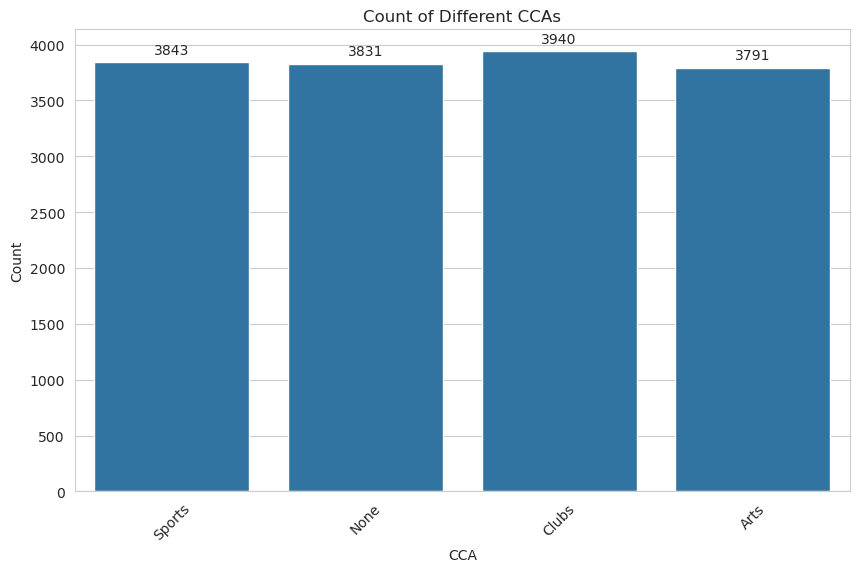

In [142]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Bar chart for flat type with annotations
plt.figure(figsize=(10, 6))
count_plot = sns.countplot(x='CCA', data=df)
plt.title('Count of Different CCAs')
plt.xlabel('CCA')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Annotate the bars with the frequency count
for p in count_plot.patches:
    count_plot.annotate(format(p.get_height(), '.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points')

plt.show()

In [137]:
df['CCA'] = df['CCA'].replace('ARTS', 'Arts')
df['CCA'] = df['CCA'].replace('SPORTS', 'Sports')
df['CCA'] = df['CCA'].replace('NONE', 'None')
df['CCA'] = df['CCA'].replace('CLUBS', 'Clubs')

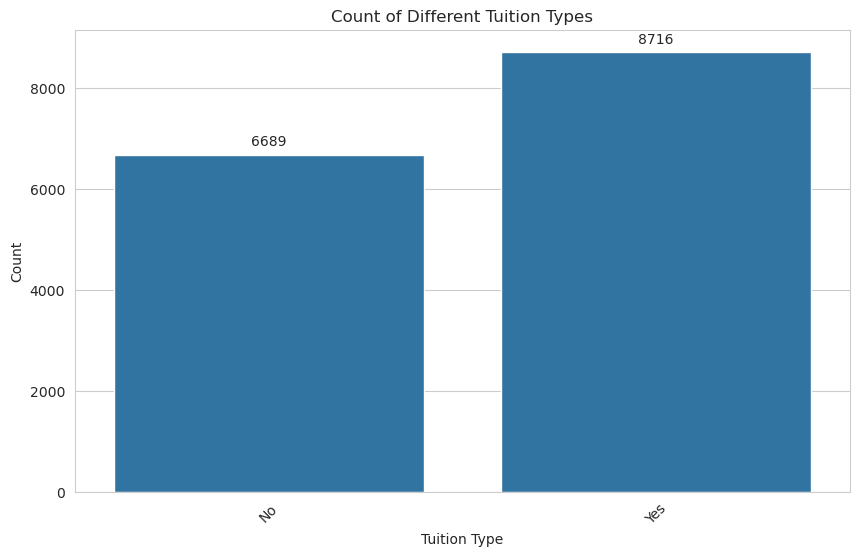

In [140]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Bar chart for flat type with annotations
plt.figure(figsize=(10, 6))
count_plot = sns.countplot(x='tuition', data=df)
plt.title('Count of Different Tuition Types')
plt.xlabel('Tuition Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Annotate the bars with the frequency count
for p in count_plot.patches:
    count_plot.annotate(format(p.get_height(), '.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points')

plt.show()

In [139]:
df['tuition'] = df['tuition'].replace('Y', 'Yes')
df['tuition'] = df['tuition'].replace('N', 'No')

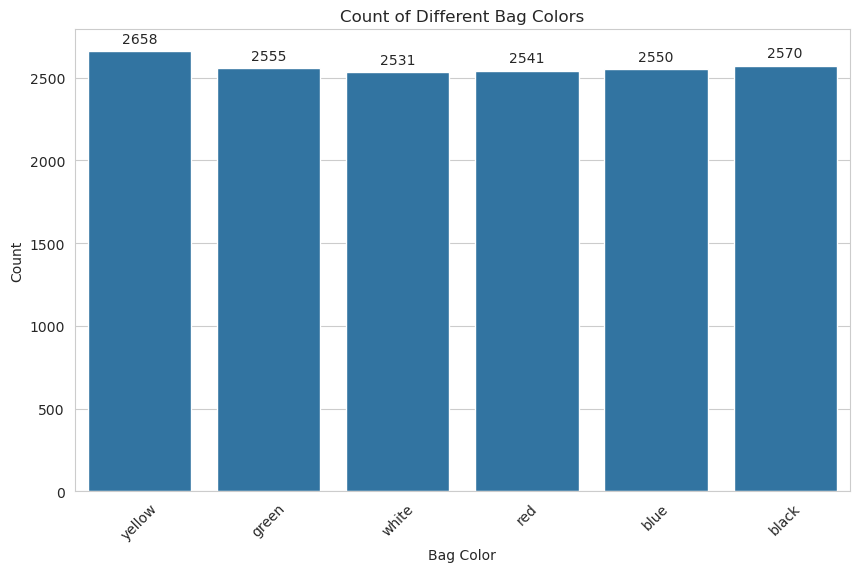

In [141]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Bar chart for flat type with annotations
plt.figure(figsize=(10, 6))
count_plot = sns.countplot(x='bag_color', data=df)
plt.title('Count of Different Bag Colors')
plt.xlabel('Bag Color')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Annotate the bars with the frequency count
for p in count_plot.patches:
    count_plot.annotate(format(p.get_height(), '.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points')

plt.show()

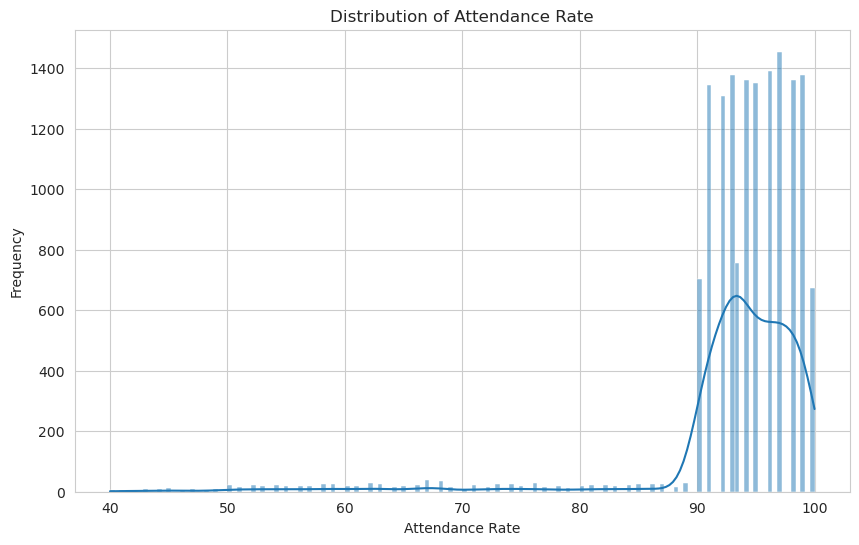

In [143]:
# Set the aesthetic style of the plots  
sns.set_style("whitegrid")  
  
# Histogram for age  
plt.figure(figsize=(10, 6))  
sns.histplot(df['attendance_rate'], kde=True)  
plt.title('Distribution of Attendance Rate')  
plt.xlabel('Attendance Rate')  
plt.ylabel('Frequency')  
plt.show()

In [145]:
# Convert sleep_time / wake_time strings to total minutes since midnight
sleep_min = pd.to_datetime(df['sleep_time'], format='%H:%M').dt.hour * 60 \
          + pd.to_datetime(df['sleep_time'], format='%H:%M').dt.minute
wake_min  = pd.to_datetime(df['wake_time'],  format='%H:%M').dt.hour * 60 \
          + pd.to_datetime(df['wake_time'],  format='%H:%M').dt.minute

# Sleep duration in hours; add 24h when the interval wraps past midnight
df['sleep_hours_daily'] = ((wake_min - sleep_min) % (24 * 60)) / 60

df[['sleep_time', 'wake_time', 'sleep_hours_daily']]


,sleep_time,wake_time,sleep_hours_daily
0,22:00,6:00,8.0
1,22:30,6:30,8.0
2,22:30,6:30,8.0
3,21:00,5:00,8.0
4,21:30,5:30,8.0
...,...,...,...
15895,22:00,6:00,8.0
15896,22:30,6:30,8.0
15897,23:00,7:00,8.0
15898,23:00,7:00,8.0


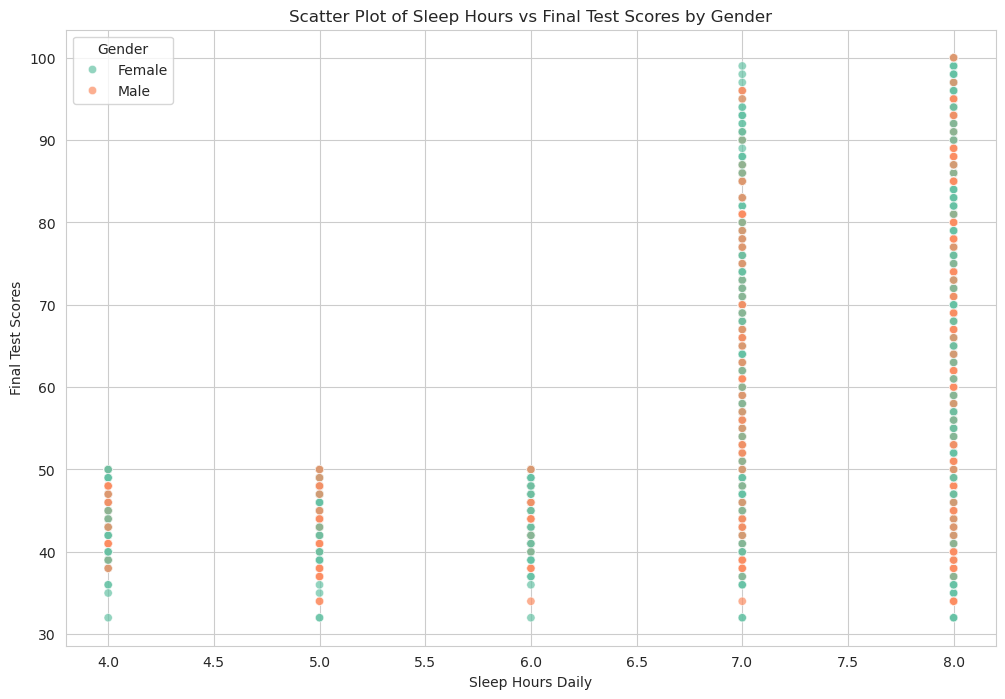

In [146]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Scatter plot for floor area vs resale price with color encoding for flat type
plt.figure(figsize=(12, 8))
sns.scatterplot(x='sleep_hours_daily', y='final_test', hue='gender', data=df, palette='Set2', alpha=0.7)
plt.title('Scatter Plot of Sleep Hours vs Final Test Scores by Gender')
plt.xlabel('Sleep Hours Daily')
plt.ylabel('Final Test Scores')
plt.legend(title='Gender')
plt.show()

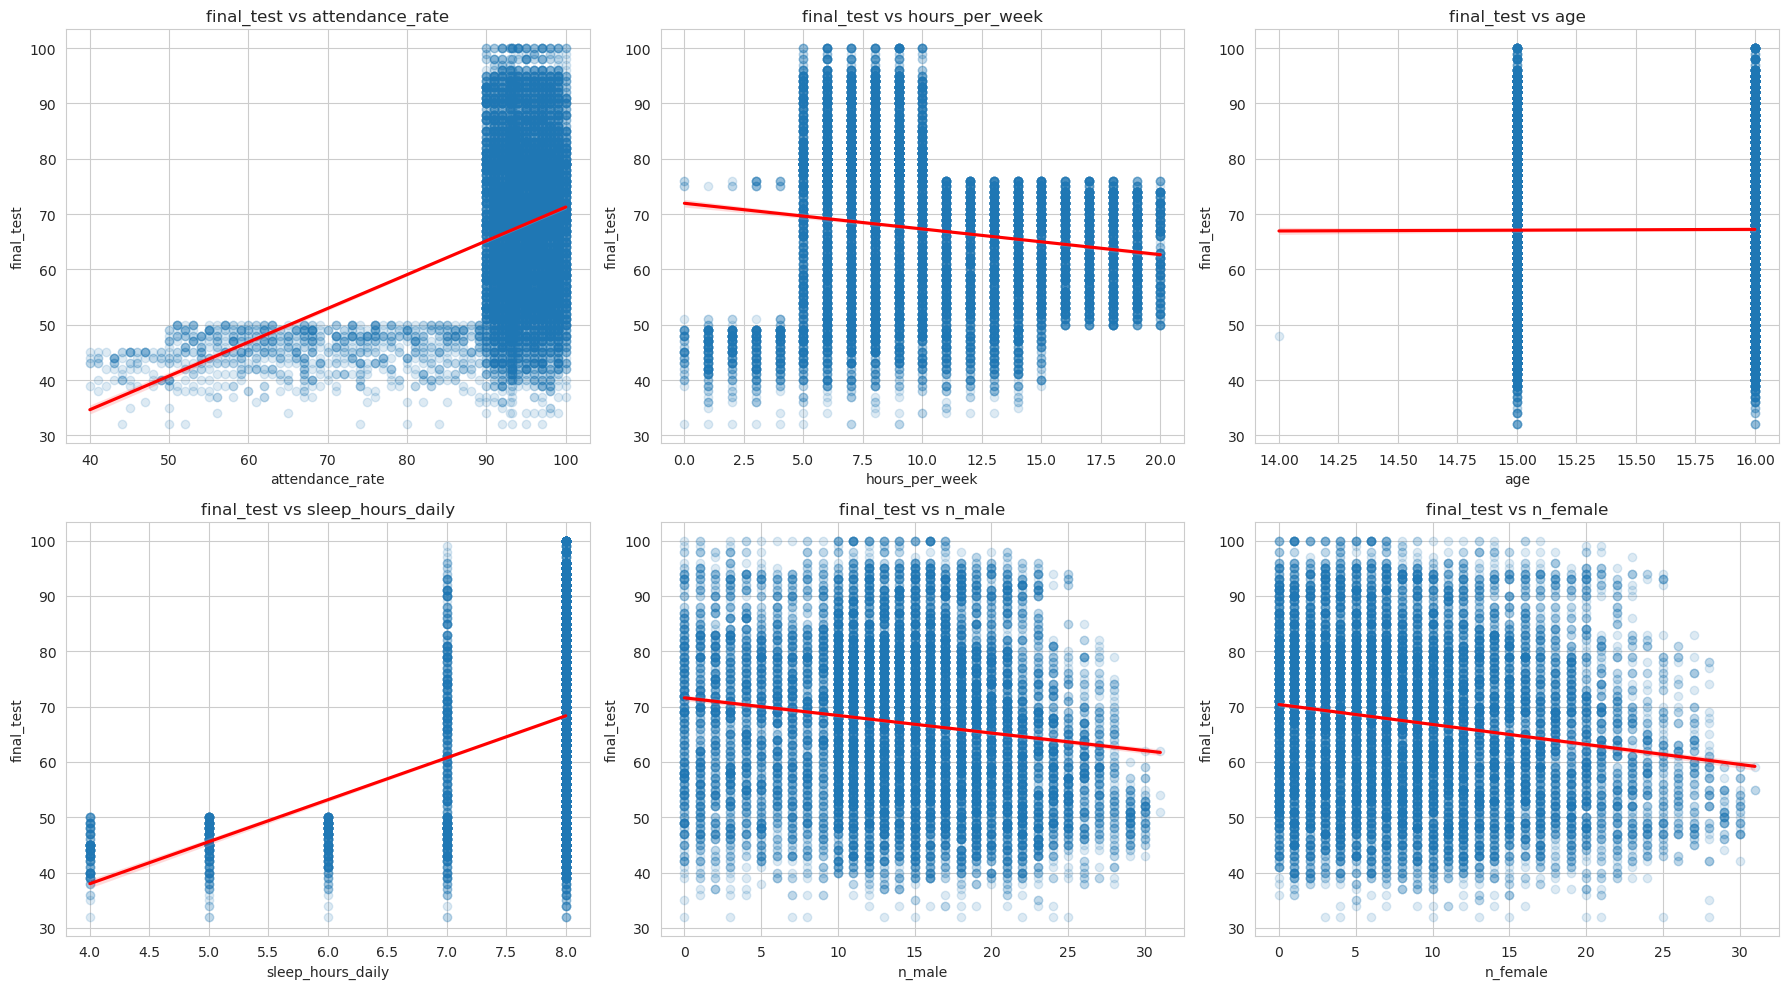

In [160]:
num_features = ['attendance_rate', 'hours_per_week', 'age', 'sleep_hours_daily', 'n_male', 'n_female']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flat, num_features):
    sns.regplot(x=col, y='final_test', data=df, ax=ax,
                scatter_kws={'alpha': 0.15}, line_kws={'color': 'red'})
    ax.set_title(f'final_test vs {col}')
plt.tight_layout()
plt.show()


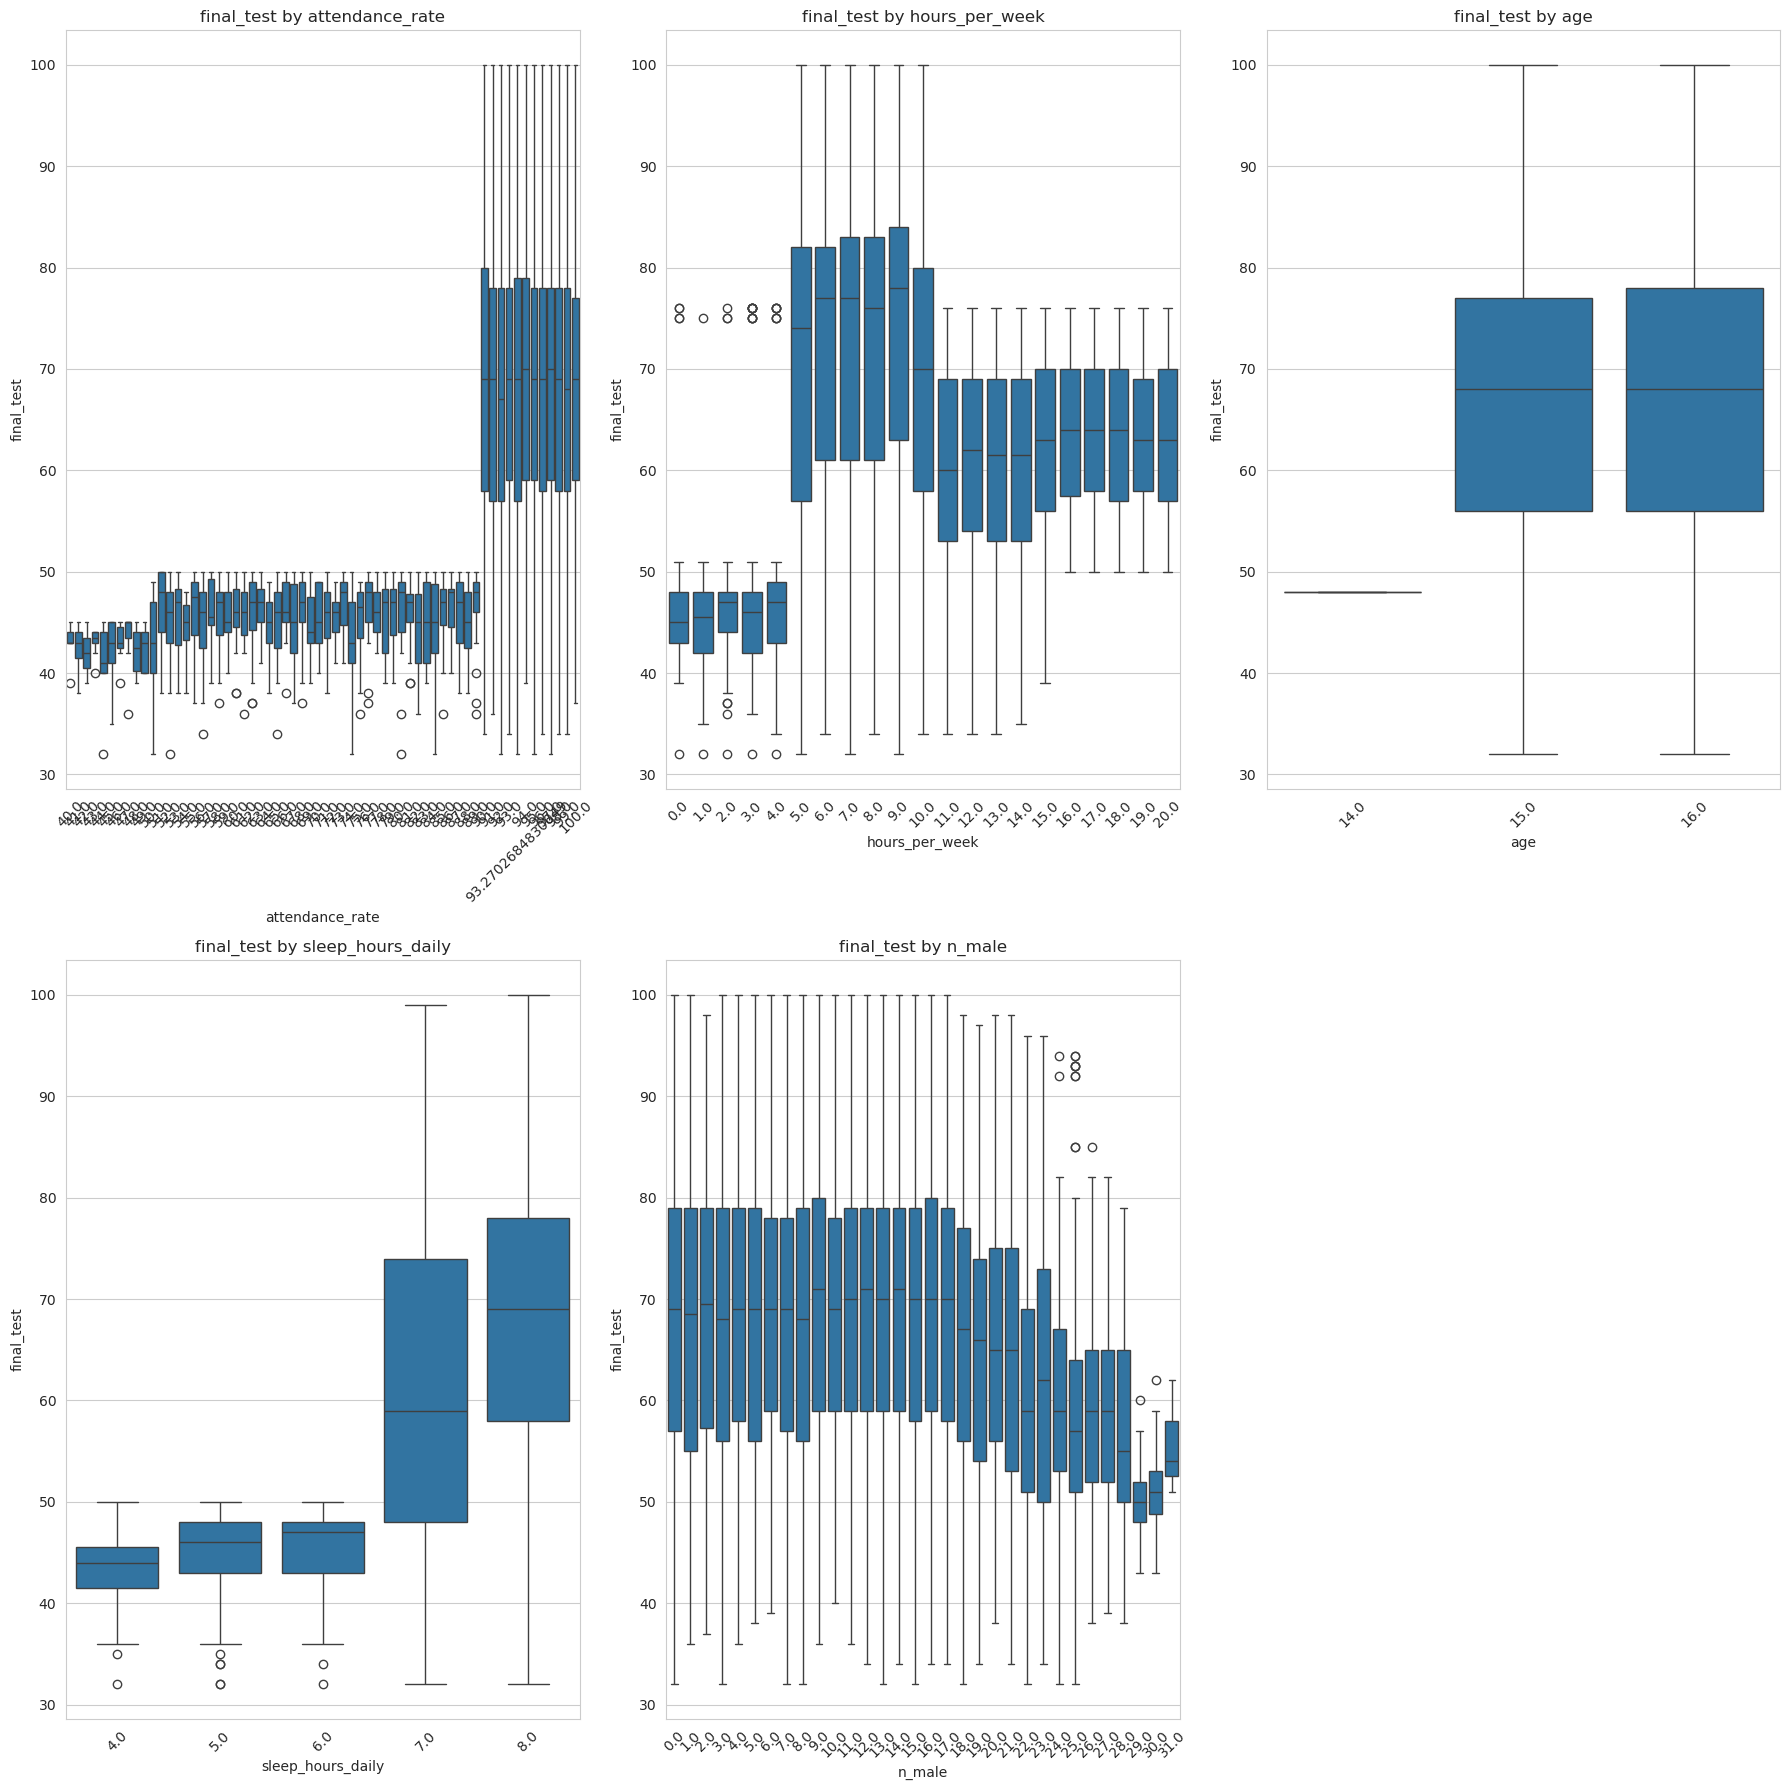

In [172]:
cat_features = ['attendance_rate', 'hours_per_week', 'age', 'sleep_hours_daily', 'n_male', 'n_female']

fig, axes = plt.subplots(2, 3, figsize=(18, 18))
for ax, col in zip(axes.flat, cat_features):
    sns.boxplot(x=col, y='final_test', data=df, ax=ax)
    ax.set_title(f'final_test by {col}')
    ax.tick_params(axis='x', rotation=45)
fig.delaxes(axes.flat[5])  # only 6 features, remove the empty 6th panel
plt.tight_layout()
plt.show()


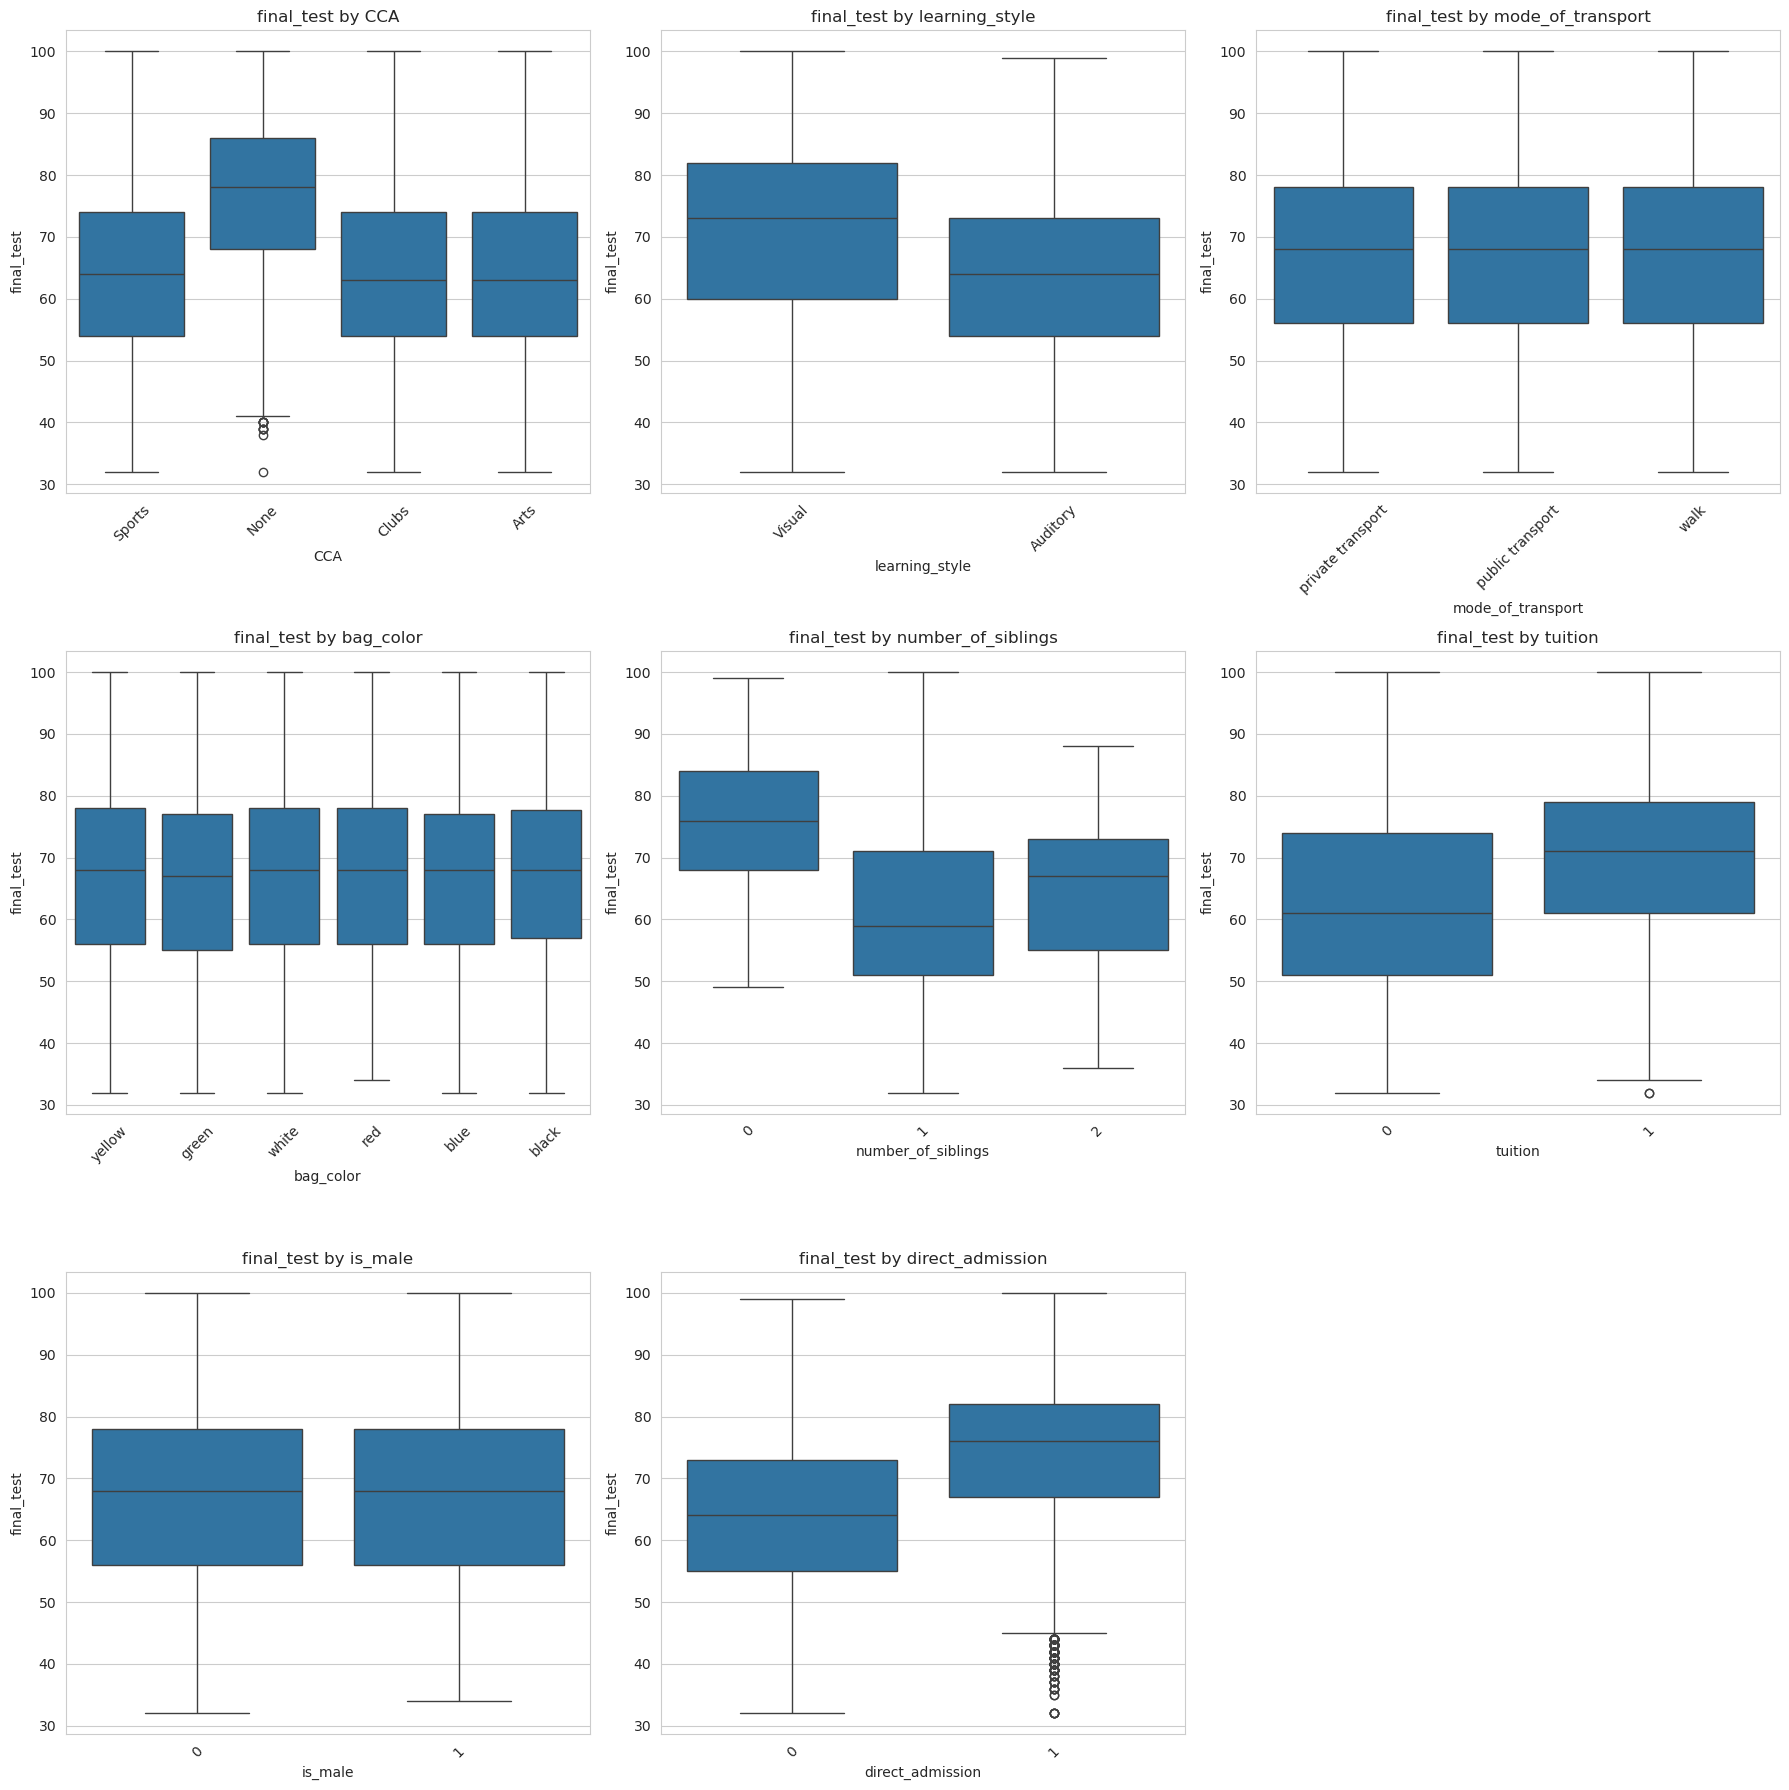

In [ ]:
cat_features = ['CCA', 'learning_style', 'mode_of_transport', 'bag_color', 'number_of_siblings', 'tuition', 'is_male', 'direct_admission']

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
for ax, col in zip(axes.flat, cat_features):
    sns.boxplot(x=col, y='final_test', data=df, ax=ax)
    ax.set_title(f'final_test by {col}')
    ax.tick_params(axis='x', rotation=45)
fig.delaxes(axes.flat[8])  # only 8 features, remove the empty 9th panel
plt.tight_layout()
plt.show()


In [162]:
for col in ['is_male', 'tuition', 'direct_admission']:
    print(f"\n{col}:")
    print(df.groupby(col)['final_test'].agg(['mean', 'count']))


is_male:
              mean  count
is_male                  
0        66.999869   7661
1        67.329158   7744

tuition:
              mean  count
tuition                  
0        62.864404   6689
1        70.466154   8716

direct_admission:
                       mean  count
direct_admission                  
0                 64.989500  10857
1                 72.359719   4548


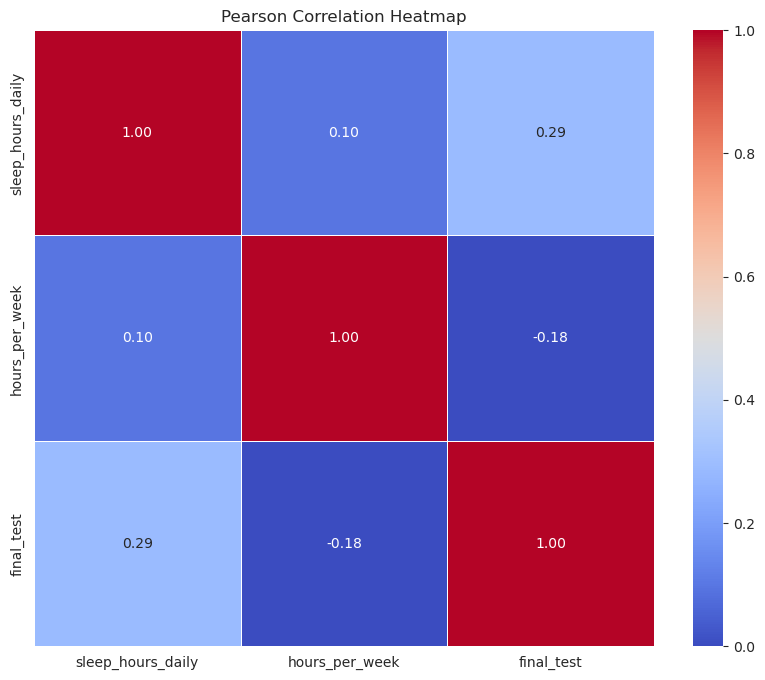

In [148]:
# Select continuous variables  
continuous_vars_all = df[['sleep_hours_daily', 'hours_per_week', 'final_test']]

# Calculate the Pearson correlation matrix for the entire dataset
corr_matrix_pear = continuous_vars_all.corr(method='spearman')

# Plot the heatmap of the correlation matrix for the entire dataset
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_pear, annot=True, cmap='coolwarm', vmin=0, center=0.5, vmax=1, linewidths=0.5, fmt=".2f")
plt.title('Pearson Correlation Heatmap')
plt.show()

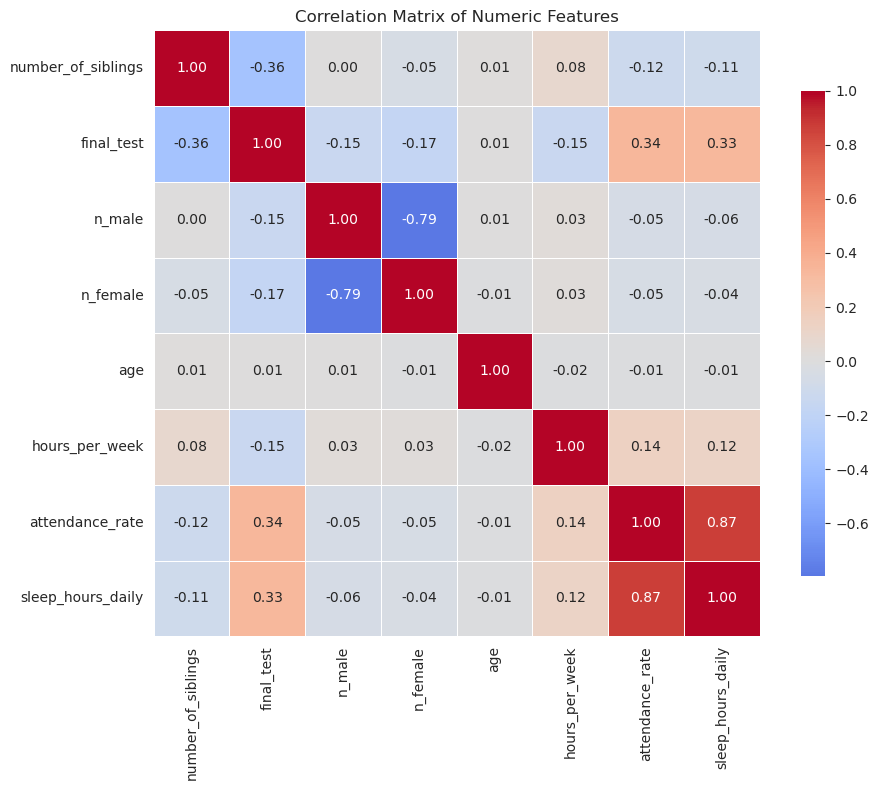

In [149]:
# --- Correlation analysis (numeric features) ---

# Select numeric columns; drop 'index' since it's just a row id, not a real feature
numeric_cols = df.select_dtypes(include='number').columns.drop('index', errors='ignore')

corr = df[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()


In [150]:
# Correlation of each numeric feature with the target, strongest first
target_corr = corr['final_test'].drop('final_test').sort_values(key=abs, ascending=False)
print(target_corr)


number_of_siblings   -0.363767
attendance_rate       0.340307
sleep_hours_daily     0.327213
n_female             -0.171978
n_male               -0.149152
hours_per_week       -0.148254
age                   0.005179
Name: final_test, dtype: float64


In [ ]:
# --- Binary encoding for Yes/No and gender features ---

binary_map = {'Yes': 1, 'No': 0}
df = df.rename(columns={'gender': 'is_male'})

df['direct_admission'] = df['direct_admission'].replace(binary_map)
df['tuition']          = df['tuition'].replace(binary_map)
df['is_male']           = df['is_male'].replace({'Male': 1, 'Female': 0})

# Verify the encoding
df[['direct_admission', 'tuition', 'is_male']].head()


,direct_admission,tuition,is_male
0,1,0,0
1,0,0,0
2,1,0,1
3,0,1,0
4,0,0,1


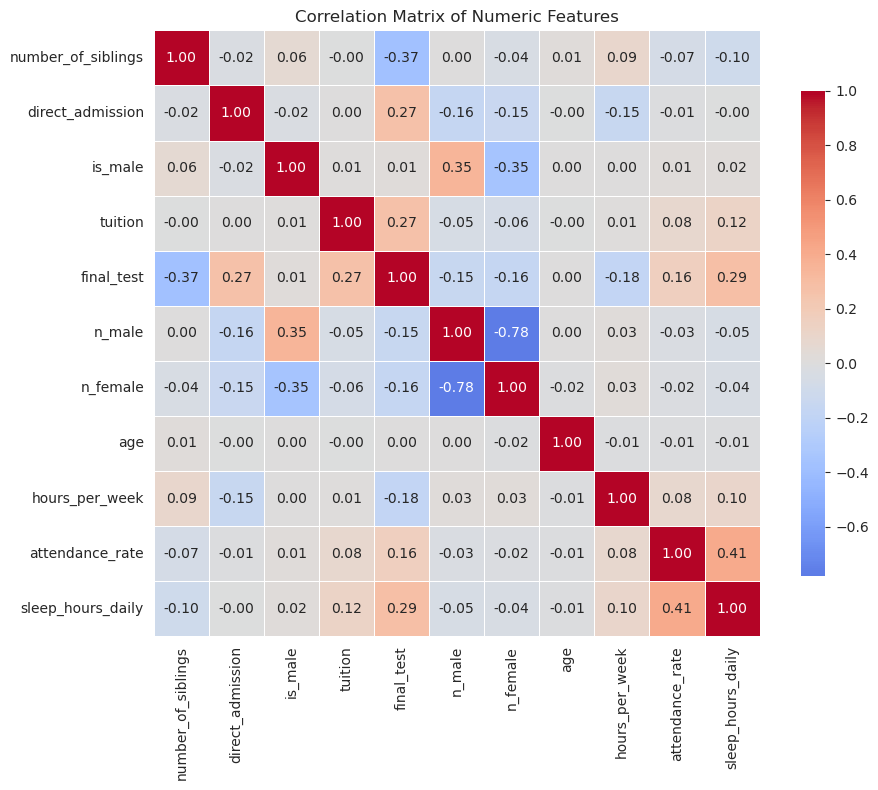

In [175]:
# --- Correlation analysis (numeric features) ---

# Select numeric columns; drop 'index' since it's just a row id, not a real feature
numeric_cols = df.select_dtypes(include='number').columns.drop('index', errors='ignore')

corr = df[numeric_cols].corr(method = 'spearman')

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()


In [156]:
# Correlation of each numeric feature with the target, strongest first
target_corr = corr['final_test'].drop('final_test').sort_values(key=abs, ascending=False)
print(target_corr)


number_of_siblings   -0.369936
sleep_hours_daily     0.287414
direct_admission      0.267925
tuition               0.267439
hours_per_week       -0.180432
attendance_rate       0.162740
n_female             -0.161848
n_male               -0.152408
is_male               0.012640
age                   0.004166
Name: final_test, dtype: float64


In [176]:
# Correlation of each numeric feature with the target, strongest first
target_corr = corr['final_test'].drop('final_test').sort_values(key=abs, ascending=False)
print(target_corr)


number_of_siblings   -0.369936
sleep_hours_daily     0.287414
direct_admission      0.267925
tuition               0.267439
hours_per_week       -0.180432
attendance_rate       0.162740
n_female             -0.161848
n_male               -0.152408
is_male               0.012640
age                   0.004166
Name: final_test, dtype: float64


In [37]:
# Drop the 'block' and 'street_name' columns
df = df.drop(columns=['block', 'street_name'])

In [38]:
# Separate the data into features and target
X = df.drop(columns='resale_price')
y = df['resale_price']

In [39]:
X

,month,flat_type,storey_range,floor_area_sqm,lease_commence_date,town_name,flatm_name,year,remaining_lease_months
0,5,5 ROOM,8.0,123.0,1989,PASIR RIS,Improved,2018,843
1,10,4 ROOM,2.0,100.0,1999,SENGKANG,Model A,2016,972
2,10,5 ROOM,20.0,110.0,2002,CHOA CHU KANG,Improved,2018,990
3,12,4 ROOM,14.0,103.0,1984,HOUGANG,Model A,2015,804
4,9,5 ROOM,8.0,122.0,1992,SERANGOON,Improved,2017,890
...,...,...,...,...,...,...,...,...,...
84460,9,5 ROOM,11.0,111.0,2001,SEMBAWANG,Improved,2015,1020
84461,6,5 ROOM,8.0,110.0,2002,ANG MO KIO,Improved,2015,1032
84462,9,5 ROOM,2.0,110.0,2003,HOUGANG,Improved,2017,1018
84463,4,4 ROOM,2.0,91.0,1984,ANG MO KIO,New Generation,2016,792


In [40]:
y

0        488000.0
1        345000.0
2        370000.0
3        432000.0
4        500000.0
           ...   
84460    468000.0
84461    760000.0
84462    380000.0
84463    406000.0
84464    425000.0
Name: resale_price, Length: 84465, dtype: float64

In [42]:
from sklearn.model_selection import train_test_split

# Split the data into training (80%) and test-validation (20%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the test-validation set (20%) into validation (10%) and test (10%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [43]:
# Display the shapes of the splits to verify
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (67572, 9) (67572,)
Validation set shape: (8446, 9) (8446,)
Test set shape: (8447, 9) (8447,)
